In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image


%matplotlib inline

- sexo: sexo del estudiante (1: mujer)
- edad: edad del estudiante (meses)
- imce: indice de masa corporal estandarizado (puntaje z)
- vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)
- vive_madre: 2 si la madre vive en el hogar (2 indica que tiene mas de una madre)
- area: urbana=1, rural=0
- sk1: muestra afecto a padres (1: siempre - 5: nunca)
- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)
- sk3: expresa sus sentimientos (1: siempre - 5: nunca)
- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)
- sk5: juega con otros (1: siempre - 5: nunca)
- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)
- sk7: es agresivo (1: siempre - 5: nunca)
- sk8: participa en juegos grupales (1: siempre - 5: nunca)
- sk9: hace preguntas a adultos (1: siempre - 5: nunca) 
- sk10: tiene interes por libros (1: siempre - 5: nunca) 
- sk11: tiene interes por su entorno (1: siempre - 5: nunca)
- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca) 
- sk13: tiene expresiones artisticas (1: siempre - 5: nunca) 
- act_fisica: frecuencia actividad fisica (1: nunca - 5: 5 o mas veces a la semana)
- educm: años de escolaridad de la madre
- educp: años de escolaridad del padre
- madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)

1. 

In [3]:
df1=pd.read_csv('junaeb3.csv')
df1.describe()

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
count,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,...,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,30051.000000,31055.000000,30682.000000,31055.000000,31055.000000
mean,0.538979,82.589084,1.017787,0.720335,0.966511,1.114088,1.391177,1.262856,1.256352,1.268588,...,1.333666,1.853743,1.385349,1.502785,1.694735,2.556620,0.911544,13.069291,12.955756,0.092803
std,0.498486,4.360270,1.370552,0.449415,0.189671,0.394004,0.650190,0.585766,0.578266,0.564929,...,0.666009,0.941171,0.668783,0.799375,0.984946,1.068041,0.283961,3.338320,3.425190,0.943509
min,0.000000,62.000000,-5.020000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,80.000000,0.120000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,12.000000,11.000000,-1.000000
50%,1.000000,81.000000,0.970000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,13.000000,13.000000,0.000000
75%,1.000000,82.000000,1.930000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.000000,15.000000,14.000000,1.000000
max,1.000000,107.000000,5.040000,2.000000,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,22.000000,22.000000,1.000000


In [4]:
df_sk = df1[[f'sk{i}' for i in range(1,14)]].copy()
df_sk['sk7'] = 6 - df_sk['sk7']
df_sk.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31055 entries, 0 to 31054
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   sk1     31055 non-null  int64
 1   sk2     31055 non-null  int64
 2   sk3     31055 non-null  int64
 3   sk4     31055 non-null  int64
 4   sk5     31055 non-null  int64
 5   sk6     31055 non-null  int64
 6   sk7     31055 non-null  int64
 7   sk8     31055 non-null  int64
 8   sk9     31055 non-null  int64
 9   sk10    31055 non-null  int64
 10  sk11    31055 non-null  int64
 11  sk12    31055 non-null  int64
 12  sk13    31055 non-null  int64
dtypes: int64(13)
memory usage: 3.1 MB


No existen null en los sk's, por lo que un _dropna_ no será necesario, además se invierte el sentido de sk7 ya que es de connotación negtiva, más adelante veremos que variables son significativas para cada modelo y cual podemos descartar. 

2.

In [5]:
fa = FactorAnalyzer(rotation='varimax').fit(df_sk)
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.183970, 0.549198, 0.155598],
       [0.177203, 0.517433, 0.350410],
       [0.182944, 0.596588, 0.168045],
       [0.198779, 0.686060, 0.200987],
       [0.121309, 0.219980, 0.724979],
       [0.173086, 0.210702, 0.481159],
       [-0.069524, -0.074626, -0.136478],
       [0.269342, 0.104813, 0.478344],
       [0.495931, 0.215337, 0.207927],
       [0.563365, 0.122575, 0.127228],
       [0.664883, 0.209988, 0.205834],
       [0.526984, 0.116246, 0.144172],
       [0.485171, 0.154101, 0.134872]])

In [6]:
fa.get_eigenvalues()[0]

array([4.114952, 1.341624, 1.100575, 1.000161, 0.781977, 0.698537,
       0.695787, 0.684453, 0.604042, 0.523209, 0.512081, 0.487796,
       0.454807])

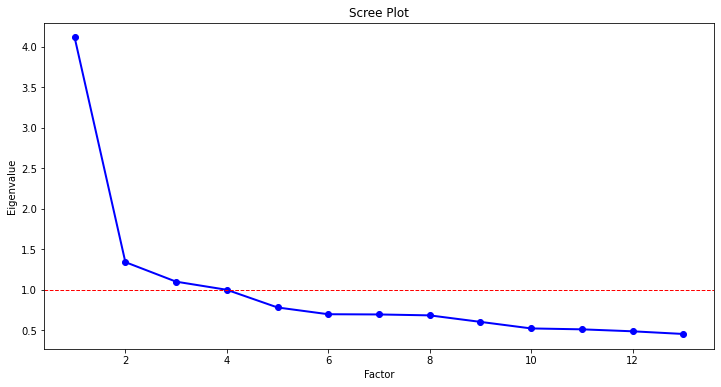

In [7]:
values = np.arange(1,14)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.figure(figsize=(12, 6))
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue')
plt.axhline(1, color='red', linestyle='--', linewidth=1)
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

Vemos claramente como se forma un codo con dos factores, por lo que tomaremos esta configuración como primera opción:

In [8]:
fa = FactorAnalyzer(rotation='varimax', n_factors=2).fit(df_sk)
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.544433, 0.168621],
       [0.639659, 0.193829],
       [0.578932, 0.175454],
       [0.661521, 0.195791],
       [0.499339, 0.254957],
       [0.417627, 0.245437],
       [-0.137482, -0.085336],
       [0.323907, 0.338242],
       [0.273662, 0.511502],
       [0.151393, 0.563508],
       [0.262579, 0.673274],
       [0.152455, 0.537187],
       [0.183986, 0.488821]])

In [9]:
fa.get_factor_variance()[2][:]

array([0.173059, 0.322447])

In [10]:
fa.get_communalities()

array([0.324840, 0.446733, 0.365946, 0.475945, 0.314343, 0.234651,
       0.026184, 0.219323, 0.336525, 0.340461, 0.522246, 0.311813,
       0.272797])

Vemos en [9] que la varianza acumulada es de un 32%, lo que indica que con dos factores no estamos explicando una gran parte de la varianza de los datos. Por lo que se opta por el criterio de dejar todos aquellos factores con un valor propio mayor a 1

In [11]:
fa.get_eigenvalues()[0][3]

1.0001606732123345

Si bien esta muy al límite alcanza a superar uno por lo que en este modelo usaremos 4 factores. 

In [12]:
fa = FactorAnalyzer(rotation='varimax', n_factors=4).fit(df_sk)
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.179220, 0.521750, 0.062918, 0.315360],
       [0.173856, 0.486274, 0.258577, 0.369580],
       [0.199616, 0.632740, 0.171230, -0.029259],
       [0.216855, 0.695906, 0.191845, 0.039809],
       [0.138459, 0.228331, 0.740685, 0.128042],
       [0.176714, 0.178838, 0.412680, 0.313400],
       [-0.058745, -0.029790, -0.062723, -0.295514],
       [0.287356, 0.116554, 0.464761, 0.067503],
       [0.507360, 0.214436, 0.190703, 0.045422],
       [0.565324, 0.094034, 0.071719, 0.169465],
       [0.667603, 0.194712, 0.165143, 0.123248],
       [0.533830, 0.115109, 0.130746, 0.026176],
       [0.487336, 0.142442, 0.105435, 0.087389]])

In [13]:
for i in range(1, 14):
    print (f'sk{i}: {fa.get_communalities()[i-1]:.4f}')

sk1: 0.4078
sk2: 0.4701
sk3: 0.4704
sk4: 0.5697
sk5: 0.6363
sk6: 0.3317
sk7: 0.0956
sk8: 0.3167
sk9: 0.3418
sk10: 0.3623
sk11: 0.5261
sk12: 0.3160
sk13: 0.2765


Vemos acá que con 4 factores (lo cual es harto) se explica tan solo un 9% de la varianza de sk7 por lo que lo podemos conciderar descartable, ya que no entra en ningun grupo. 

In [14]:
df_sk = df_sk.drop(columns=['sk7'])
fa = FactorAnalyzer(rotation='varimax', n_factors=4).fit(df_sk)
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.199214, 0.428295, 0.114913, 0.333055],
       [0.167053, 0.329436, 0.277316, 0.727069],
       [0.187375, 0.597364, 0.170896, 0.130160],
       [0.196316, 0.735401, 0.194389, 0.133002],
       [0.124426, 0.194595, 0.790709, 0.105628],
       [0.197004, 0.164895, 0.421211, 0.176455],
       [0.283984, 0.099812, 0.455804, 0.074725],
       [0.503883, 0.229603, 0.199611, 0.026651],
       [0.571486, 0.079935, 0.096713, 0.118272],
       [0.668488, 0.191173, 0.184205, 0.093979],
       [0.528177, 0.110625, 0.135921, 0.043881],
       [0.488924, 0.122475, 0.115983, 0.102992]])

In [15]:
fa.get_factor_variance()

(array([1.821570, 1.387534, 1.282555, 0.758128]),
 array([0.151798, 0.115628, 0.106880, 0.063177]),
 array([0.151798, 0.267425, 0.374305, 0.437482]))

Ahora con 4 podemos explicar un 44%, mejora pero no es tan bueno aún, aunque lo dejaremos así ya que aumentar tantos factores no es una buena práctica y tampoco aumentaría tanto este valor. 

3.

In [16]:
factor_scores = fa.transform(df_sk) 
factor_df = pd.DataFrame(data=factor_scores, columns=['Factor1', 'Factor2', 'Factor3', 'Factor4'])
dfa = pd.merge(df1, factor_df, left_index=True, right_index=True);

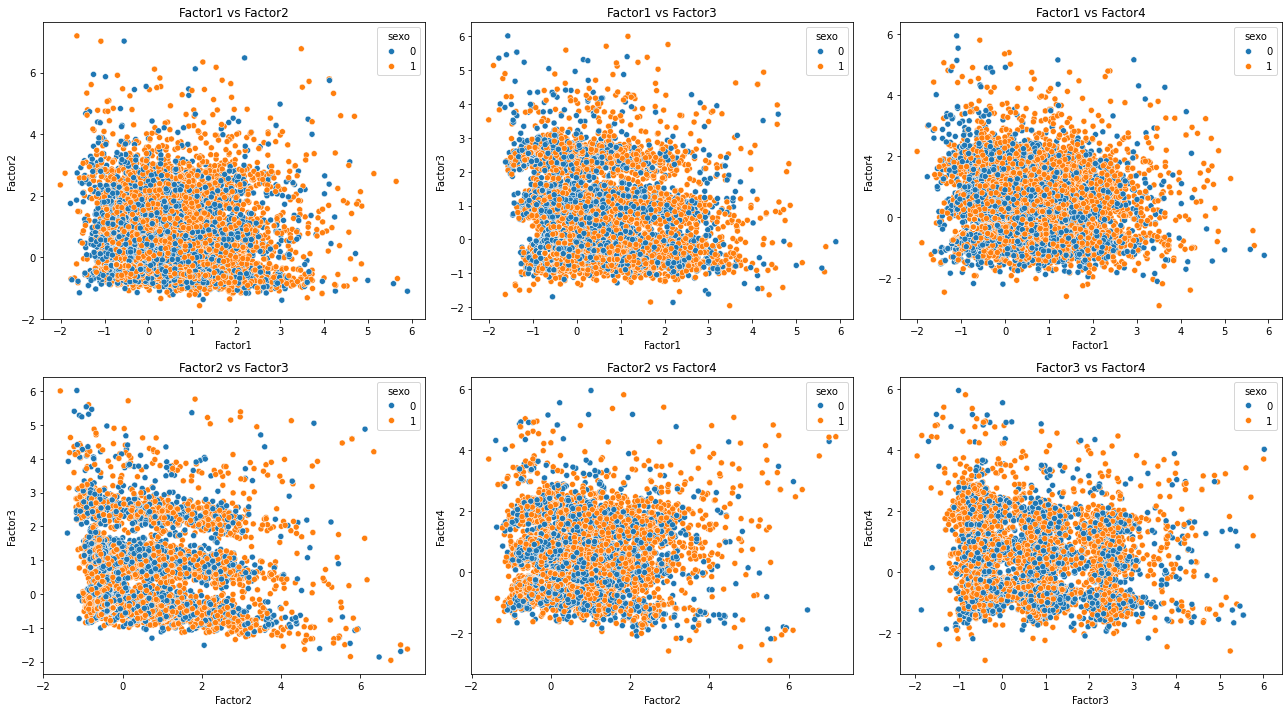

In [17]:
pairs = [(i, j) for i in range(1, 5) for j in range(i + 1, 5)]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (i, j) in zip(axes, pairs):
    sns.scatterplot(data=dfa, x=f'Factor{i}', y=f'Factor{j}', hue='sexo', ax=ax)
    ax.set_title(f'Factor{i} vs Factor{j}')
plt.tight_layout()

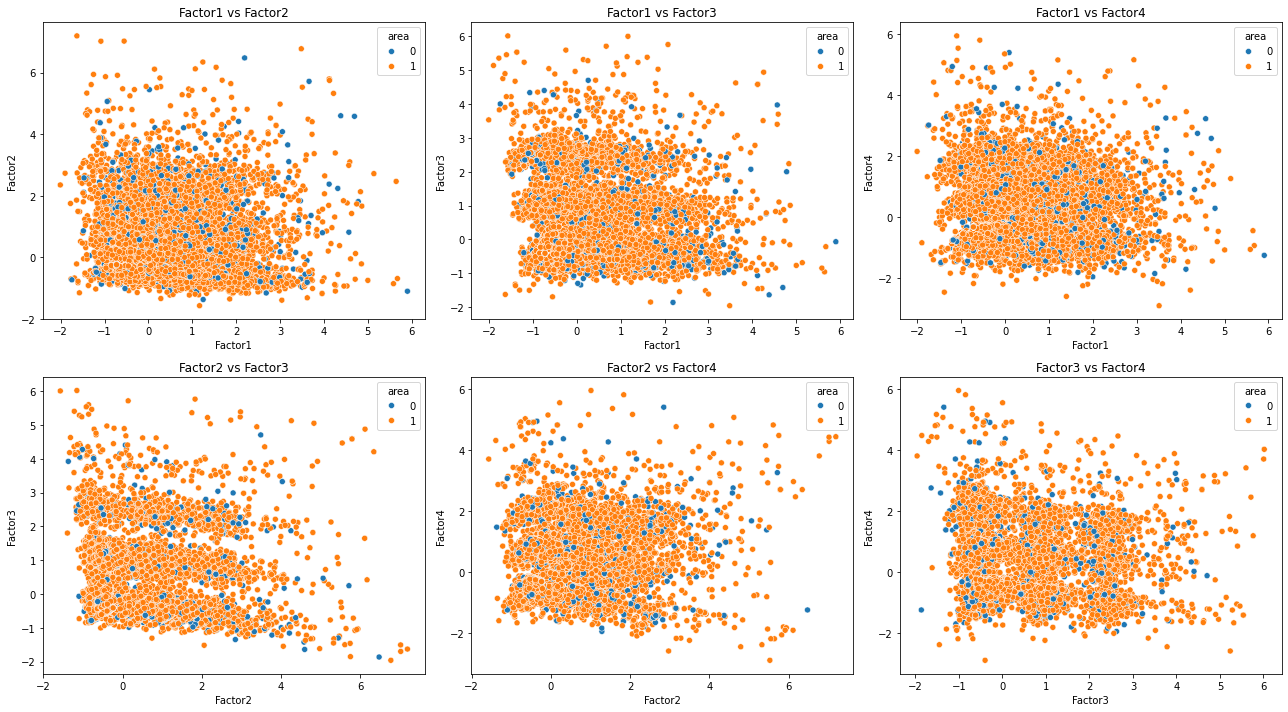

In [18]:
pairs = [(i, j) for i in range(1, 5) for j in range(i + 1, 5)]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (i, j) in zip(axes, pairs):
    sns.scatterplot(data=dfa, x=f'Factor{i}', y=f'Factor{j}', hue='area', ax=ax)
    ax.set_title(f'Factor{i} vs Factor{j}')
plt.tight_layout()

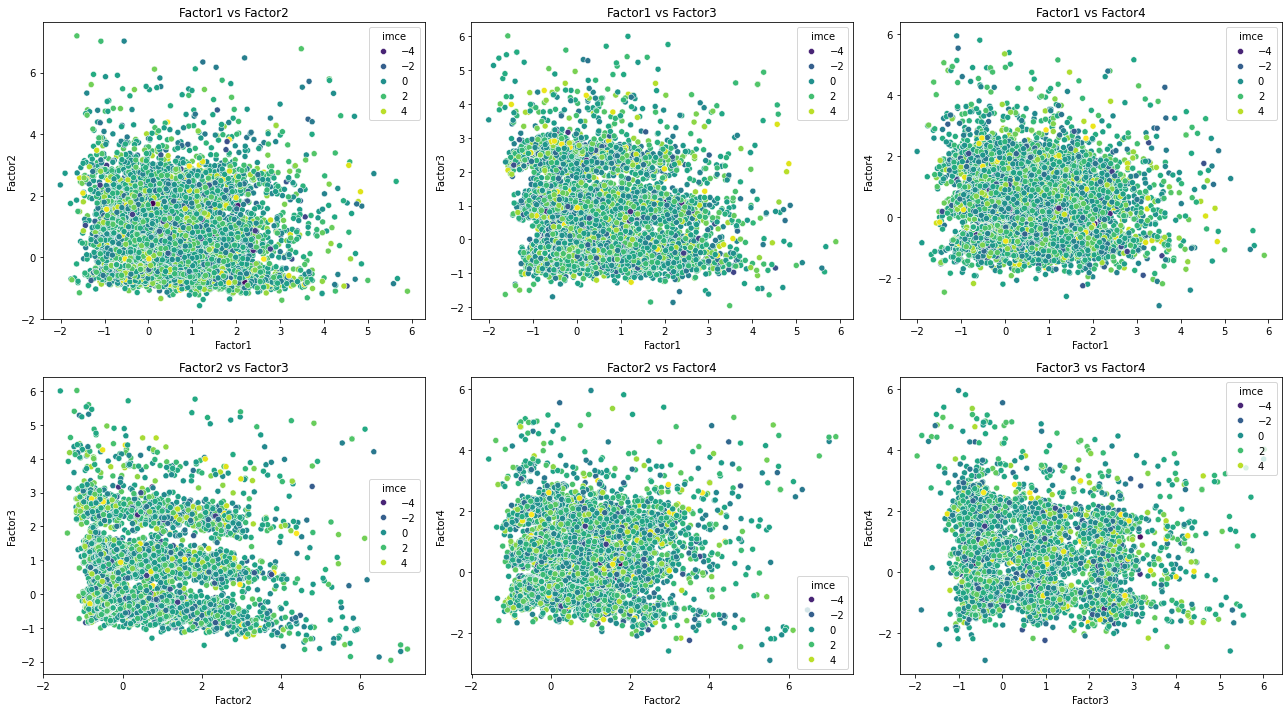

In [19]:
pairs = [(i, j) for i in range(1, 5) for j in range(i + 1, 5)]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (i, j) in zip(axes, pairs):
    sns.scatterplot(data=dfa, x=f'Factor{i}', y=f'Factor{j}', hue='imce', ax=ax, palette='viridis')
    ax.set_title(f'Factor{i} vs Factor{j}')
plt.tight_layout()

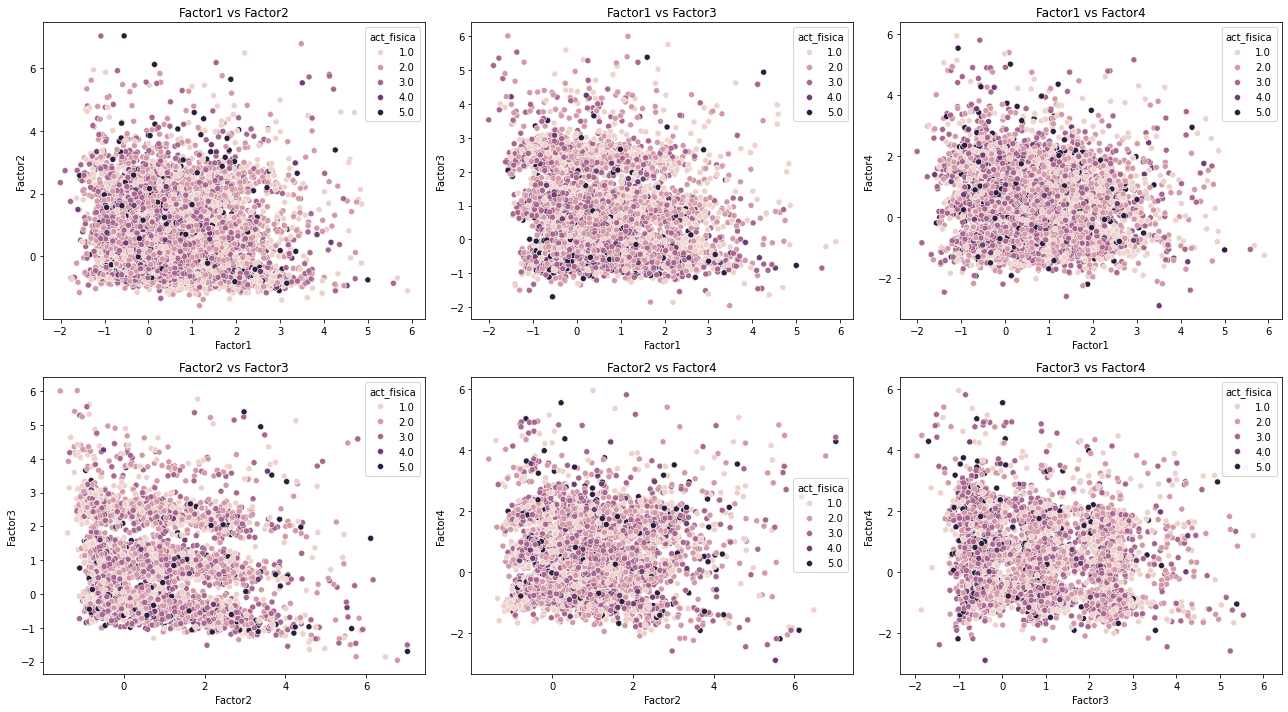

In [20]:
pairs = [(i, j) for i in range(1, 5) for j in range(i + 1, 5)]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (i, j) in zip(axes, pairs):
    sns.scatterplot(data=dfa, x=f'Factor{i}', y=f'Factor{j}', hue='act_fisica', ax=ax)
    ax.set_title(f'Factor{i} vs Factor{j}')
plt.tight_layout()

Vemos que ningun gráfico presenta segrecación de los factores, vemos solo ruido. 

4. 

In [21]:
fa.loadings_

array([[0.199214, 0.428295, 0.114913, 0.333055],
       [0.167053, 0.329436, 0.277316, 0.727069],
       [0.187375, 0.597364, 0.170896, 0.130160],
       [0.196316, 0.735401, 0.194389, 0.133002],
       [0.124426, 0.194595, 0.790709, 0.105628],
       [0.197004, 0.164895, 0.421211, 0.176455],
       [0.283984, 0.099812, 0.455804, 0.074725],
       [0.503883, 0.229603, 0.199611, 0.026651],
       [0.571486, 0.079935, 0.096713, 0.118272],
       [0.668488, 0.191173, 0.184205, 0.093979],
       [0.528177, 0.110625, 0.135921, 0.043881],
       [0.488924, 0.122475, 0.115983, 0.102992]])

Como elegimos entre 3 y 4 factores tan al límite, vamos a ver que modelo es mejor. El de tres factores se basa en los loadings que vimos por defecto en una primera instancia que venia de a 3 factores, y el de 4, es con el que nos quedamos en la pregunta 2

In [22]:
mod1 = """
# measurement model
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13
eta2 =~ sk1 + sk2 +sk3 + sk4
eta3 =~ sk5 + sk6 + sk8
    """


mod2 = """
# measurement model
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13
eta2 =~ sk1 + sk3 +sk4
eta3 =~ sk5 + sk6 + sk8
eta4 =~  sk2 
"""

model1 = semopy.Model(mod1)
out1=model1.fit(df_sk)

model2 = semopy.Model(mod2)
out2=model2.fit(df_sk)
print (semopy.calc_stats(model1))
print('-----')
print (semopy.calc_stats(model2))

       DoF  DoF Baseline         chi2  chi2 p-value  chi2 Baseline       CFI  \
Value   51            66  4401.365973           0.0   87611.052581  0.950307   

            GFI      AGFI       NFI       TLI     RMSEA        AIC  \
Value  0.949762  0.934987  0.949762  0.935692  0.052411  53.716544   

              BIC    LogLik  
Value  278.991452  0.141728  
-----
       DoF  DoF Baseline         chi2  chi2 p-value  chi2 Baseline       CFI  \
Value   48            66  3567.641916           0.0   87611.052581  0.959796   

            GFI      AGFI       NFI      TLI     RMSEA        AIC        BIC  \
Value  0.959279  0.944008  0.959279  0.94472  0.048593  59.770237  310.07569   

         LogLik  
Value  0.114881  


Ambos tienen un chi2 p-value de 0, por lo que son significativos, pero el modelo 1 tiene un menor bic por lo que nos aseguramos que es un modelo sencillo y sin sobreajuste, aunque bien este beneficio es muy marginal al del modelo 2

In [ ]:
print (out1)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.115
Number of iterations: 40
Params: 1.330 1.229 1.089 1.257 1.649 1.841 1.043 1.161 0.161 0.055 0.096 0.104 0.055 0.092 0.163 0.056 0.139 0.143 0.101 0.601 0.204 0.448 0.716 0.279 0.194 0.149 0.156 0.373 0.477 0.283


In [24]:
model1.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,eta1,1.000000,0.600501,-,-,-
1,sk10,~,eta1,1.334713,0.567130,0.017645,75.641962,0.0
2,sk11,~,eta1,1.232807,0.737146,0.013993,88.102986,0.0
3,sk12,~,eta1,1.091950,0.546278,0.014832,73.622089,0.0
4,sk13,~,eta1,1.261417,0.512138,0.017981,70.151539,0.0
5,sk1,~,eta2,1.000000,0.595909,-,-,-
6,sk2,~,eta2,1.793157,0.647690,0.021586,83.072223,0.0
7,sk3,~,eta2,1.603422,0.642710,0.019395,82.673817,0.0
8,sk4,~,eta2,1.777960,0.721890,0.020174,88.132298,0.0
9,sk5,~,eta3,1.000000,0.719657,-,-,-


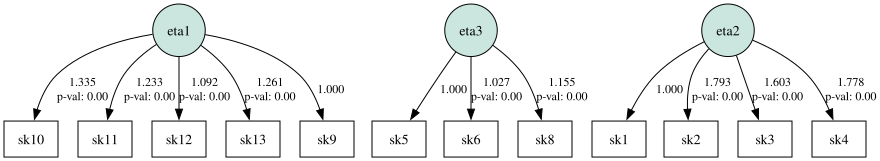

In [25]:
semopy.semplot(model1, "model.png")


La magnitud de los parametros del modelo indican relaciones saludables entre las variables latentes y las observadas, además ninguna presenta un p-value>0.5

5. 

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:02<00:00,  2.62s/it, max_LL=-4.3e+5, max_avg_LL=-13.9]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:05<00:00,  5.81s/it, max_LL=-4.29e+5, max_avg_LL=-13.8]


Fitting StepMix...


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:14<00:00, 14.31s/it, max_LL=-4.29e+5, max_avg_LL=-13.8]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:09<00:00,  9.84s/it, max_LL=-4.29e+5, max_avg_LL=-13.8]


<Axes: >

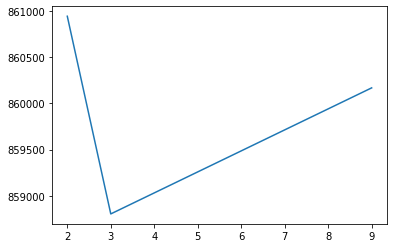

In [26]:
from stepmix.stepmix import StepMix

# Numero optimo de clusters CLASES LATENTES
K = range(2, 10)
fits = []
BIC = []

for k in K:
    # train the model for current value of k on training data
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123).fit(df_sk)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    BIC.append(model.sabic(df_sk))

sns.lineplot(x = K, y = BIC)    

En este set de datos ocurre algo muy curioso, ya que despues de 3 componentes el BIC no sigue disminuyendo si no que aumenta, por lo que simplemente nos quedaremos con 3. 

In [27]:
df_cl = df1[['imce']]
# Ajustar modelo con 3 clases
model = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123)
model.fit(df_cl)
df_cl['pred']= model.predict(df_cl)


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:02<00:00,  2.35s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce            2.4074  0.5922 -1.9669
    Class weights
        Class 1 : 0.27
        Class 2 : 0.71
        Class 3 : 0.02
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 31055
    Number of latent classes      : 3
    Number of estimated parameters: 5
    Log-likelihood (LL)           : -53735.8888
    -2LL                          : 107471.7775
    Average LL                    : -1.7303
    AIC                           : 107481.78
    BIC                           : 107523.50
    CAIC                          : 107528.50
    Sample-Size Adjusted BIC      : 107559.32
    Entropy                       : 11958.6120
    Scaled Relative Entropy       : 0.6495



/var/folders/1b/_0my04wn0l5fq3m24vckmcmc0000gn/T/ipykernel_50282/732862712.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cl['pred']= model.predict(df_cl)


La magnitud de la Scaled Relative Entropy nos indica que el modelo es bueno y vemos que como el imc está normalizado la clase 2 va hasta -2, y la clase 0 desde 2.4, estando la gran mayoria de los datos en la clase 1 como se ve en los pesos, existe además mucho más sobrepeso que desnutrición. 

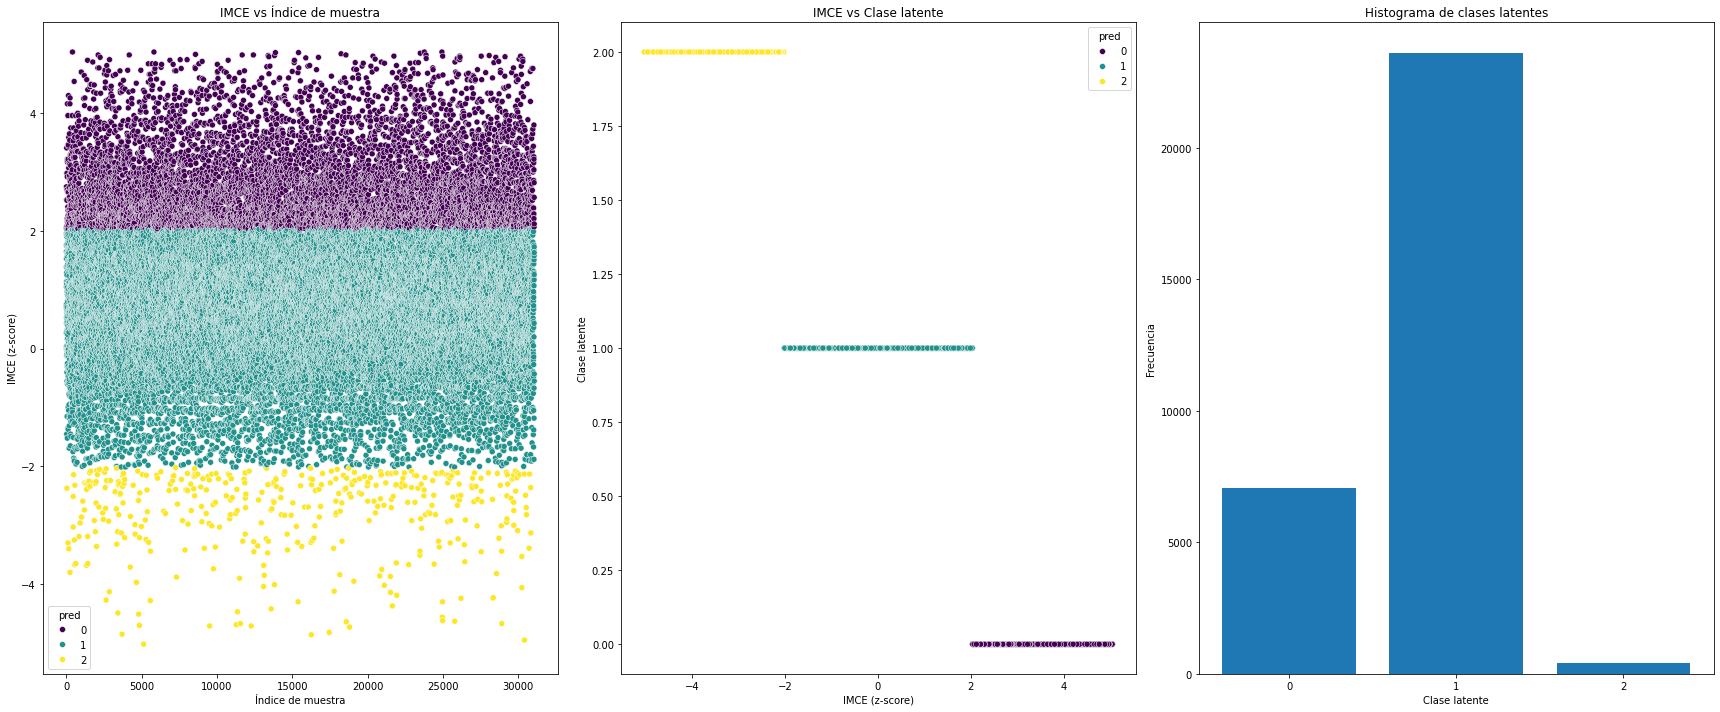

In [28]:

fig, axes = plt.subplots(1, 3, figsize=(24, 10))

# Scatter: índice vs IMCE
sns.scatterplot(
    data=df_cl,
    x=np.arange(len(df_cl)),
    y='imce',
    hue='pred',
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('IMCE vs Índice de muestra')
axes[0].set_xlabel('Índice de muestra')
axes[0].set_ylabel('IMCE (z-score)')

# Scatter: IMCE vs clase latente
sns.scatterplot(
    data=df_cl,
    x='imce',
    y='pred',
    hue='pred',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('IMCE vs Clase latente')
axes[1].set_xlabel('IMCE (z-score)')
axes[1].set_ylabel('Clase latente')

# Histograma de clases latentes
axes[2].hist(
    df_cl['pred'],
    bins=range(df_cl['pred'].nunique() + 1),
    align='left',
    rwidth=0.8)
axes[2].set_xticks(sorted(df_cl['pred'].unique()))
axes[2].set_xlabel('Clase latente')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Histograma de clases latentes')

plt.tight_layout()
plt.show()


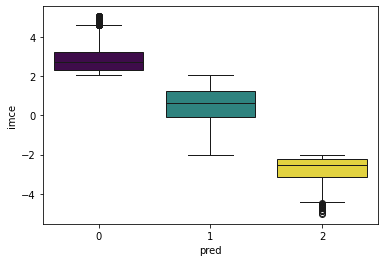

In [29]:
sns.boxplot(data=df_cl, x='pred', y='imce', palette='viridis', hue='pred', legend=False)
plt.show()

6. 

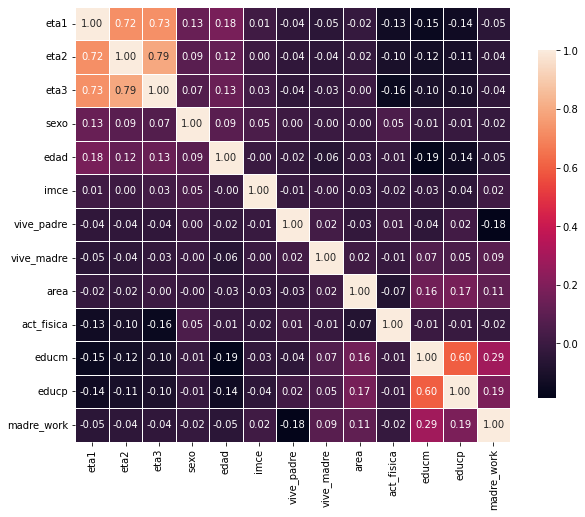

In [30]:
cfa = pd.DataFrame(data=model1.predict_factors(df_sk), columns=['eta1', 'eta2', 'eta3'])
df_cfa = pd.merge(df1, cfa, left_index=True, right_index=True)

cols = [
    'eta1', 'eta2', 'eta3',
    'sexo',
    'edad',
    'imce',
    'vive_padre',
    'vive_madre',
    'area',
    'act_fisica',
    'educm',
    'educp',
    'madre_work'
]

# Extraer sub-DataFrame y calcular la matriz de varianza–covarianza
corr_matrix = df_cfa[cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.show()

          eta1      eta2      eta3      sexo      edad      imce  vive_padre  \
eta1  0.124746  0.053329  0.089602  0.022719  0.271444  0.006717   -0.005608   
eta2  0.053329  0.043456  0.057464  0.009390  0.112088  0.001403   -0.003577   
eta3  0.089602  0.057464  0.120488  0.012452  0.203619  0.011996   -0.005960   

      vive_madre      area  act_fisica     educm     educp  madre_work  
eta1   -0.003487 -0.001796   -0.049381 -0.181549 -0.166691   -0.017200  
eta2   -0.001604 -0.001266   -0.022780 -0.085819 -0.078943   -0.008274  
eta3   -0.001896 -0.000033   -0.056984 -0.119450 -0.113635   -0.011498  


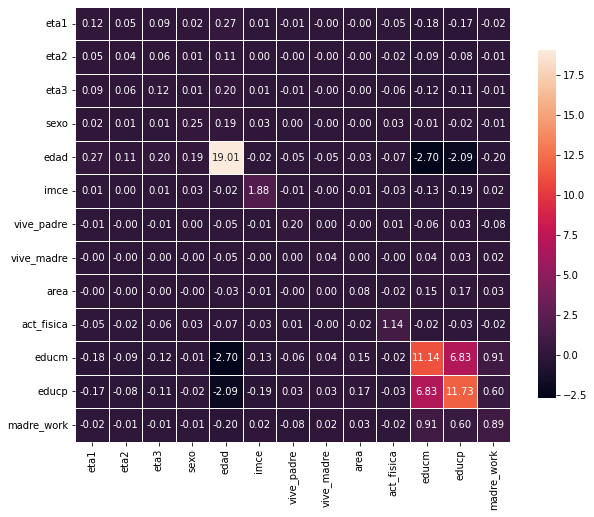

In [31]:
cov_matrix = df_cfa[cols].cov()
print (cov_matrix[:3][:])
# Visualizar la matriz de covarianza
plt.figure(figsize=(10, 8))
sns.heatmap(
    cov_matrix,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.show()

Se identifica del modelo anterior, que:
- eta1 : desarrollo sentimental 
- eta2 : desarrollo lúdico y social
- eta3 : desarrollo intelectual

Por lo que en base a esa interpretación y respaldado por la matriz de correlación, se propone el siguiente modelo: 

In [ ]:
mod_sem = '''
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13
eta2 =~ sk1 + sk2 +sk3 + sk4
eta3 =~ sk5 + sk6 + sk8

imce =~ eta1 + eta2 + eta3 + sexo + edad + vive_padre + vive_madre + area + act_fisica + madre_work
eta3 =~ act_fisica 
eta1 =~ edad + educm + educp
'''

model_sem = semopy.Model(mod_sem)
out = model_sem.fit(df1)
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.909
Number of iterations: 102
Params: 1.372 1.208 1.073 1.280 2.582 -0.289 -1.861 -1.751 1.785 1.599 1.769 1.030 1.185 -0.595 0.179 0.636 1.060 0.207 -0.063 -0.037 -0.027 -0.219 1.101 0.081 18.080 10.600 11.241 0.068 0.019 0.060 0.091 0.886 0.245 0.100 0.587 0.215 0.456 0.710 0.246 0.201 0.161 0.157 0.378 0.469 0.285 0.036 0.202


In [33]:
semopy.calc_stats(model_sem)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,184,210,28214.166883,0.0,115521.968845,0.756919,0.755768,0.721257,0.755768,0.72257,0.07004,92.182955,484.328165,0.908523


EL CFI y el TLI debieran estar entre 0.90-0.95, para ser aceptable y RMSEA menor a 0.06 ya que este ultimo estima la discrepancia promedio por grado de libertad entre la matriz de covarianzas observada y la predicha por el modelo. En este caso no se cumple niingun criterio, por lo que obtenemos los parametros del modelo y vemos que es lo que esta relacionado y no es significante. 

In [34]:
model_sem.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,eta1,~,imce,1.000000,0.755971,-,-,-
1,eta2,~,imce,0.635524,0.812799,0.011174,56.873146,0.0
2,eta3,~,imce,1.059892,0.792396,0.01738,60.984253,0.0
3,sk9,~,eta1,1.000000,0.598492,-,-,-
4,sk10,~,eta1,1.371806,0.581000,0.01778,77.154548,0.0
5,sk11,~,eta1,1.208448,0.720266,0.013767,87.778813,0.0
6,sk12,~,eta1,1.073269,0.535196,0.014761,72.708068,0.0
7,sk13,~,eta1,1.280246,0.518142,0.018042,70.960123,0.0
8,edad,~,eta1,2.582246,0.236078,0.151134,17.085763,0.0
9,edad,~,imce,-0.288548,-0.019943,0.206672,-1.396167,0.162664


Ajustamos aquellas relaciones debiles, siempre teniendo en cuenta el contexto que ya dimos de cada eta y la matrices de correlaciones y covarinzas. 

In [38]:
mod_sem = '''
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13
eta2 =~ sk1 + sk2 +sk3 + sk4
eta3 =~ sk5 + sk6 + sk8

imce =~ eta1 + eta2 + eta3 + sexo + edad 
eta3 =~ act_fisica 
eta1 ~ educm + educp + area
eta2 ~ vive_padre + vive_madre + madre_work
'''

model_sem = semopy.Model(mod_sem)
out = model_sem.fit(df1)
semopy.calc_stats(model_sem)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,192,216,10909.83632,0.0,115521.964821,0.907049,0.905561,0.893756,0.905561,0.89543,0.042398,77.297386,402.694475,0.351307


Se cumplen los criterios y el modelo queda así:

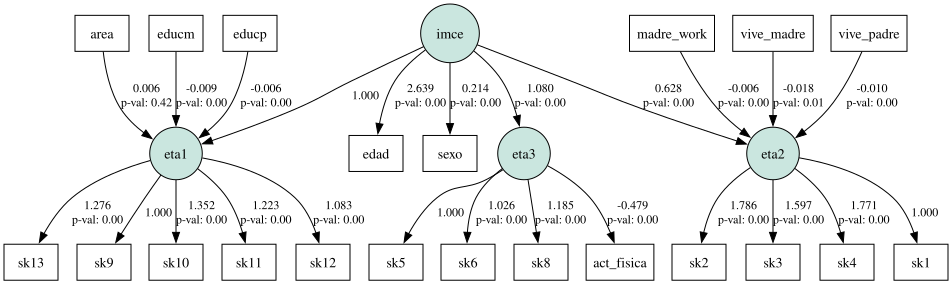

In [37]:
semopy.semplot(model_sem, "sem.png")